In [1]:
import keras
import numpy as np
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train.shape

2026-03-18 19:56:12.850915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773860172.862470  494103 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773860172.866307  494103 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-18 19:56:12.878316: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(60000, 28, 28)

In [2]:
x_train.shape[0]

60000

In [3]:
x_test.shape[0]

10000

In [4]:
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [5]:
img_rows = 28
img_cols = 28
# Reshape to include the channel dimension (for grayscale images)
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)

# Define input shape
input_shape = (img_rows, img_cols, 1)

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [7]:
# Convolutional Encoder
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
model_enc = keras.Sequential()
model_enc.add(keras.Input(shape = input_shape))
model_enc.add(keras.layers.Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same'))
model_enc.add(keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
model_enc.add(keras.layers.Conv2D(8,kernel_size=(3, 3), activation='relu', padding='same'))
model_enc.add(keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
model_enc.add(keras.layers.Conv2D(8,kernel_size=(3, 3), activation='relu', padding='same'))
model_enc.add(keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'))
model_enc.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,904 (7.44 KB)

 Trainable params: 1,904 (7.44 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# convolutional decoder
model_dec = keras.Sequential()
model_dec.add(keras.Input(shape = (4,4,8)))
model_dec.add(keras.layers.Conv2D(8, kernel_size=(3,3), activation='relu', padding='same'))
model_dec.add(keras.layers.UpSampling2D(size=(2,2)))
model_dec.add(keras.layers.Conv2D(8, kernel_size=(3,3), activation='relu', padding='same'))
model_dec.add(keras.layers.UpSampling2D(size=(2,2)))
model_dec.add(keras.layers.Conv2D(1, kernel_size=(3,3), activation='relu'))
model_dec.add(keras.layers.UpSampling2D(size=(2,2)))
model_dec.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 1)      │            73 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,241 (4.85 KB)

 Trainable params: 1,241 (4.85 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from keras.src.losses import mean_squared_error
# Autoencoder
model = keras.Sequential()
model.add(model_enc)
model.add(model_dec)
model.summary()
model.compile(optimizer='adam', loss='mean_squared_error',metrics=['mean_squared_error'])
history = model.fit(x_train, x_train, epochs=5,batch_size=128,shuffle=True,validation_split=0.2)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 4, 4, 8)        │         1,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 28, 28, 1)      │         1,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,145 (12.29 KB)

 Trainable params: 3,145 (12.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


I0000 00:00:1773860414.450884  494198 service.cc:148] XLA service 0x7c412c00e0e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773860414.450925  494198 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-03-18 20:00:14.482818: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773860414.607718  494198 cuda_dnn.cc:529] Loaded cuDNN version 90800


 92/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0709 - mean_squared_error: 0.0709  

I0000 00:00:1773860415.631388  494198 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0555 - mean_squared_error: 0.0555 - val_loss: 0.0350 - val_mean_squared_error: 0.0350
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0332 - mean_squared_error: 0.0332 - val_loss: 0.0309 - val_mean_squared_error: 0.0309
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0300 - mean_squared_error: 0.0300 - val_loss: 0.0291 - val_mean_squared_error: 0.0291
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0285 - mean_squared_error: 0.0285 - val_loss: 0.0283 - val_mean_squared_error: 0.0283
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0276 - mean_squared_error: 0.0276 - val_loss: 0.0276 - val_mean_squared_error: 0.0276


In [10]:
# predicction
output = model.predict(x_test)
output.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step    


(10000, 28, 28, 1)

In [11]:
enc_output = model_enc.predict(x_test)
enc_output.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   


(10000, 4, 4, 8)

In [12]:
dec_output = model_dec.predict(enc_output)
dec_output.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step    


(10000, 28, 28, 1)

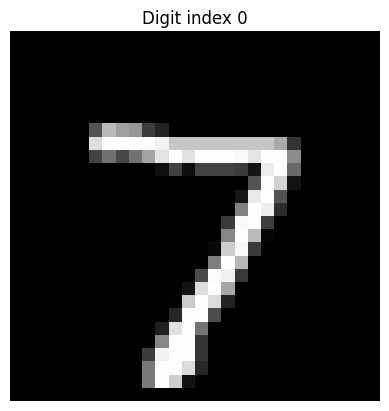

In [13]:
#check
idx = 0
import matplotlib.pyplot as plt

# x_test_cifra tiene shape (num_samples, 28, 28, 1)
im = x_test[idx, :, :, 0]  # tomar el canal 0

plt.imshow(im, cmap='gray')
plt.title(f"Digit index {idx}")
plt.axis('off')  # quitar ejes
plt.show()

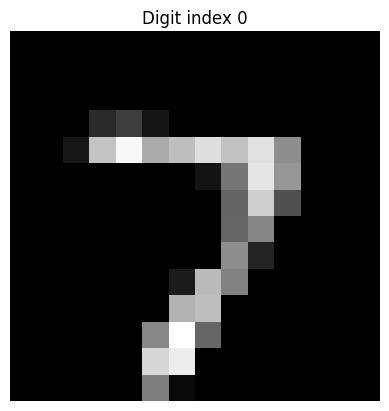

In [14]:
im = output[idx, :, :, 0]  # tomar el canal 0
plt.imshow(im, cmap='gray')
plt.title(f"Digit index {idx}")
plt.axis('off')  # quitar ejes
plt.show()

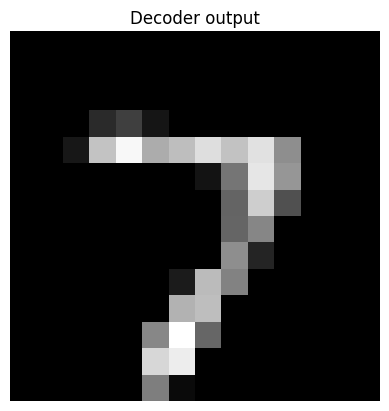

In [15]:
# Mostrar imagen decodificada
im = dec_output[idx, :, :, 0]  # canal 0
plt.imshow(im, cmap='gray')
plt.title("Decoder output")
plt.axis('off')
plt.show()



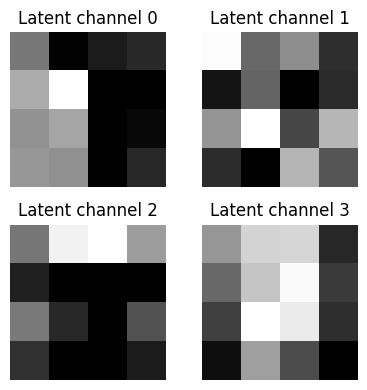

In [16]:
# Visualizar varias neuronas/canales del encoder
fig, axes = plt.subplots(2, 2, figsize=(4,4))

for k in range(4):
    # Suponiendo que enc_output_cifra[idx] tiene shape (4,4,4)
    i = k // 2
    j = k % 2
    im = enc_output[idx, :, :, k]
    axes[i,j].imshow(im, cmap='gray')
    axes[i,j].set_title(f"Latent channel {k}")
    axes[i,j].axis('off')

plt.tight_layout()
plt.show()